<a href="https://colab.research.google.com/github/Manikanta-23-ai/ML-LEARNING-ADVANCED/blob/main/MACHINE_LEARNING_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("NEXT DAY")

NEXT DAY


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
df = pd.read_csv("/content/imdb_top_1000.csv")

print(df.head())

                                         Poster_Link  \
0  https://m.media-amazon.com/images/M/MV5BMDFkYT...   
1  https://m.media-amazon.com/images/M/MV5BM2MyNj...   
2  https://m.media-amazon.com/images/M/MV5BMTMxNT...   
3  https://m.media-amazon.com/images/M/MV5BMWMwMG...   
4  https://m.media-amazon.com/images/M/MV5BMWU4N2...   

               Series_Title Released_Year Certificate  Runtime  \
0  The Shawshank Redemption          1994           A  142 min   
1             The Godfather          1972           A  175 min   
2           The Dark Knight          2008          UA  152 min   
3    The Godfather: Part II          1974           A  202 min   
4              12 Angry Men          1957           U   96 min   

                  Genre  IMDB_Rating  \
0                 Drama          9.3   
1          Crime, Drama          9.2   
2  Action, Crime, Drama          9.0   
3          Crime, Drama          9.0   
4          Crime, Drama          9.0   

                         

In [4]:
df["Released_Year"] = pd.to_numeric(
    df["Released_Year"],
    errors="coerce"
)

df["Runtime"] = df["Runtime"].str.replace(
    " min",
    "",
    regex=False
)

df["Runtime"] = pd.to_numeric(
    df["Runtime"],
    errors="coerce"
)

df["Gross"] = df["Gross"].str.replace(
    ",",
    "",
    regex=False
)

df["Gross"] = pd.to_numeric(
    df["Gross"],
    errors="coerce"
)

In [5]:
features = [
    "Released_Year",
    "Runtime",
    "Meta_score",
    "No_of_Votes",
    "Gross"
]

target = "IMDB_Rating"

In [6]:
features = [
    "Released_Year",
    "Runtime",
    "Meta_score",
    "No_of_Votes",
    "Gross"
]

target = "IMDB_Rating"

In [8]:
X = df[features]

y = df[target]

In [12]:

print(X.head())


   Released_Year  Runtime  Meta_score  No_of_Votes        Gross
0         1994.0      142        80.0      2343110   28341469.0
1         1972.0      175       100.0      1620367  134966411.0
2         2008.0      152        84.0      2303232  534858444.0
3         1974.0      202        90.0      1129952   57300000.0
4         1957.0       96        96.0       689845    4360000.0


In [13]:
print(y.head())

0    9.3
1    9.2
2    9.0
3    9.0
4    9.0
Name: IMDB_Rating, dtype: float64


In [20]:
print(df.isnull().sum())

Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score         0
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross              0
dtype: int64


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
missing_percentage = df.isnull().mean() * 100

print(missing_percentage)

Poster_Link       0.0
Series_Title      0.0
Released_Year     0.0
Certificate      10.1
Runtime           0.0
Genre             0.0
IMDB_Rating       0.0
Overview          0.0
Meta_score        0.0
Director          0.0
Star1             0.0
Star2             0.0
Star3             0.0
Star4             0.0
No_of_Votes       0.0
Gross             0.0
dtype: float64


In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [26]:

# Remove rows containing missing values
data = pd.concat([X, y], axis=1).dropna()


In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv("/content/imdb_top_1000.csv")

# Clean columns
df["Released_Year"] = pd.to_numeric(df["Released_Year"], errors="coerce")

df["Runtime"] = pd.to_numeric(
    df["Runtime"].str.replace(" min", "", regex=False),
    errors="coerce"
)

df["Gross"] = pd.to_numeric(
    df["Gross"].str.replace(",", "", regex=False),
    errors="coerce"
)

# Features
features = [
    "Released_Year",
    "Runtime",
    "Meta_score",
    "No_of_Votes",
    "Gross"
]

# Keep only required columns
data = df[features + ["IMDB_Rating"]].copy()

# REMOVE ALL ROWS CONTAINING NaN
data = data.dropna()

# Create X and y AFTER removing NaN
X = data[features]
y = data["IMDB_Rating"]

# Verify
print("Remaining NaN:")
print(X.isna().sum())

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
model = LinearRegression()

# FIT MODEL
model.fit(X_train, y_train)

print("\nModel fitted successfully.")
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Remaining NaN:
Released_Year    0
Runtime          0
Meta_score       0
No_of_Votes      0
Gross            0
dtype: int64

Model fitted successfully.
Training rows: 599
Testing rows: 150


In [30]:

y_pred = model.predict(X_test)
print("Actual Ratings:")
print(y_test.head(10).values)

print("\nPredicted Ratings:")
print(y_pred[:10])


Actual Ratings:
[7.7 7.9 8.2 8.  8.  7.9 7.9 8.1 7.7 7.6]

Predicted Ratings:
[7.77670447 7.82741814 7.94884435 7.78866577 7.93921293 7.84435903
 8.15222118 8.0456978  7.68163434 7.83141513]


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate errors
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 0.14425762704769216
MSE : 0.033574603538289644
RMSE: 0.18323374017437302
R2  : 0.5943114566903231


In [32]:
print("Coefficients:")

for feature, coefficient in zip(features, model.coef_):
    print(feature, "=", coefficient)

print("\nIntercept:", model.intercept_)

Coefficients:
Released_Year = -0.0030911595020477775
Runtime = 0.002029699111072365
Meta_score = 0.004845077481752092
No_of_Votes = 6.369045166215761e-07
Gross = -6.889998359176086e-10

Intercept: 13.311635182281083


In [33]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

coef_df["Absolute_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print(coef_df)


         Feature   Coefficient  Absolute_Coefficient
2     Meta_score  4.845077e-03          4.845077e-03
0  Released_Year -3.091160e-03          3.091160e-03
1        Runtime  2.029699e-03          2.029699e-03
3    No_of_Votes  6.369045e-07          6.369045e-07
4          Gross -6.889998e-10          6.889998e-10


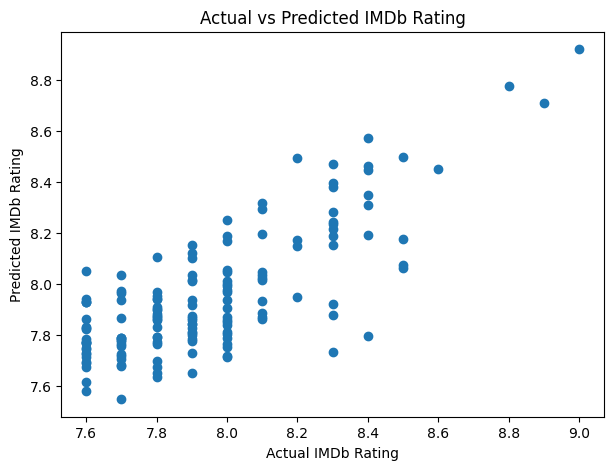

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual IMDb Rating")
plt.ylabel("Predicted IMDb Rating")
plt.title("Actual vs Predicted IMDb Rating")

plt.show()

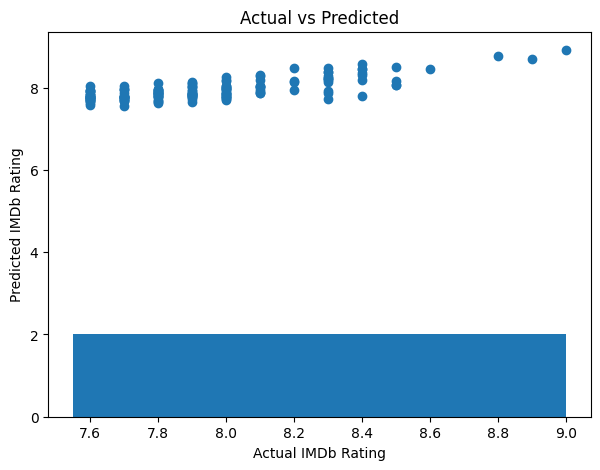

In [42]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.hist(
    [minimum, maximum],
    [minimum, maximum]
)

plt.xlabel("Actual IMDb Rating")
plt.ylabel("Predicted IMDb Rating")
plt.title("Actual vs Predicted")

plt.show()

In [37]:
residuals = y_test - y_pred

print(residuals.head(10))

793   -0.076704
508    0.072582
187    0.251156
371    0.211334
430    0.060787
546    0.055641
484   -0.252221
225    0.054302
736    0.018366
980   -0.231415
Name: IMDB_Rating, dtype: float64


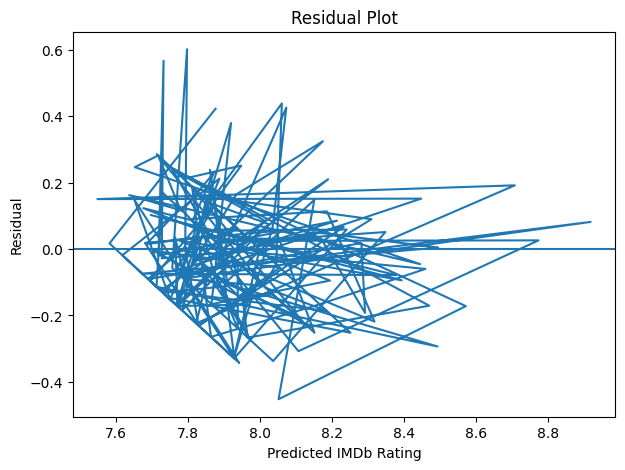

In [43]:
plt.figure(figsize=(7, 5))

plt.plot(y_pred, residuals)

plt.axhline(0)

plt.xlabel("Predicted IMDb Rating")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

In [39]:
X = data[["Runtime"]]
y = data["IMDB_Rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model_runtime = LinearRegression()

model_runtime.fit(X_train, y_train)

y_pred_runtime = model_runtime.predict(X_test)

print("R2:", r2_score(y_test, y_pred_runtime))

R2: 0.05797641918556329


In [41]:
X = data[features]
y = data["IMDB_Rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))

MAE : 0.14425762704769216
MSE : 0.033574603538289644
RMSE: 0.18323374017437302
R2  : 0.5943114566903231
